# <span style="color:blue">EVAC Workshop 6: Competitive Coevolution</span>

**Module leader**

Simon O'Keefe: simon.okeefe@york.ac.uk

**Graduate Teaching Assistants**

Colin Roitt: colin.roitt@york.ac.uk

Tianda Sun: tianda.sun@york.ac.uk

## <span style="color:#0073e6">Learning objectives</span>

- To implement a simple competitive coevolutionary algorithm using DEAP
- To understand how the populations interact and the impact of changing parameters in each population
- Implement a common version of fitness sharing (diversity measure)

# <span style="color:blue">Practical Instructions</span>

This task takes a toy game to explore competitive evolution in a simplistic domain. The game is called the Matching Game and is a coevolutionary version of the max-ones game.

In this simple immune system-inspired game, there are two populations: parasites and hosts. Each population is represented by a bit-string. Parasites are rewarded for the number of their binary genes that match the corresponding binary genes of hosts, but hosts are rewarded for the number of genes
 that mismatch with the parasites. Games of this type often result in coevolutionary cycling, because hosts chase parasites through solution space.

**Fitness function:** Not all genes are always involved in this matching game. For parasites with many 1-alleles, the matching game tends to involve only those genes at which the parasite possesses 1-alleles. For parasites with many 0-alleles, the game tends to involve only those genes at which the parasite possesses 0-alleles. Whether 1-allele genes or 0-allele genes are involved is determined probabilistically. The probability, p, of a game involving matching 1-alleles increases with the total number of 1-alleles, x, that the parasite has such that:

$p = \frac{1}{2} \{ 1+\tanh(\frac{x-50}{7}) \}$

Otherwise the game matches based on only 0-alleles for that parasite and its host opponents.

Once the game has been decided, the fitness of the host is the number of genes that it mismatches for each individual, and the fitness of the parasite is the number of genes that match for each individual.

**If you want to start with a simpler version of the problem, you can implement the game with a simple evaluation function based simply on the number of genes matched (for the parasite) or unmatched (for the host), and then move on to this more complicated version.**

If you want to read more about a coevolutionary algorithm implementing this game, then you can read the paper:

> J. Cartlidge and S. Bullock, "Combating Coevolutionary Disengagement by Reducing Parasite Virulence," in Evolutionary Computation, vol. 12, no. 2, pp. 193-222, June 2004, doi: 10.1162/106365604773955148.

A copy is available on the VLE as matchingGame.pdf.

# <span style="color:blue">Exercise 1: Implement the coevolutionary problem</span>

Your task is to implement this game in DEAP. DEAP does not implement parasitic coevolution directly. However, parasitic evolution is simply two evolutionary algorithms running simultaneously, with the fitness of each population linked. So you can implement this using your current knowledge of DEAP. Implement the problem and try to understand the results.

**Implementation Details**

I suggest using the max-ones code you developed in the first practical as a starting point.
- Use two distinct populations (species) of size 50 each (hosts / parasites)
- Individuals in each population consist of binary strings containing 100 bits, initialised at random at generation 0.
- In each generation, members of the host population are selected to play a set of pair-wise contests against a random sample of 5 opponents from the parasite population.
- Each individual has a small probability of a bit-flip mutation with a probability per gene of 0.05 (indpb=0.05) for each population
- Use tournament selection with size 6
- Run for 150 generations to start with
- **Unlike standard evolution, you should not check to see if an individual has been modified (e.g. remove ‘invalid_ind’ and ‘del mutant.fitness.values’) before assessing their fitness, because relative fitness can change even if they have not been modified. Thus, you always need to reassess fitness.**

**Things to do:**
- To explore the coevolution of the hosts and parasites, plot the average number of 1s in each generation, for each population alongside each other on a graph.
- Try giving a high mutation rate (e.g. indpb=0.1) to the parasite, and lower to the host (e.g. indpb=0.01). How does this change the coevolutionary dynamic?
- Now reverse those mutation rates, so that the host has a mutational advantage. How does this change the coevolutionary dynamic?

## <span style="color:#0073e6">Live plotting</span>

As an optional extra, we could plot progress as the code runs. You do not have to do this, and could chose to save progress and plot later too. If you choose to do it, make sure that you import 'display' from IPython first.

In [1]:
from IPython import display
import matplotlib.pyplot as plt
from deap import tools, creator, base
import numpy as np, random

In [ ]:
POPSIZE = 50
IND_SIZE = 100
NGEN = 200

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("HostIndividual", list, fitness=creator.FitnessMax)
creator.create("ParasiteIndividual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("HostIndividual", tools.initRepeat, creator.HostIndividual, toolbox.attr_bool, IND_SIZE)
toolbox.register("ParasiteIndividual", tools.initRepeat, creator.ParasiteIndividual, toolbox.attr_bool, IND_SIZE)
toolbox.register("HostPopulation", tools.initRepeat, list, toolbox.HostIndividual)
toolbox.register("ParasitePopulation", tools.initRepeat, list, toolbox.ParasiteIndividual)

def evalHost(individual):
    #To evaluate the fitness of a Host individual, we pair it with N random parasites
    #In this case N = 5
    fit = 0.0
    numOpponents = 5

    #Select N random opponents from the parasite population
    opponentIndexes = np.random.choice(len(popParasite), size=numOpponents, replace=False)
    opponents = [popParasite[i] for i in opponentIndexes]

    #For each opponent we are going to calculate a fitness of the host
    # by counting either NON-matching 1s or NON-matching 0s
    for opp in opponents:
        #Count the number of 1s in the parassite by summing the individual's genes
        x = sum(opp)

        #For this opponent, calculate the probability we will match against 1s
        #NOTE: This is inside the loop because we look at the Parasite 1s, which are different every time
        p = 0.5 * ( 1 + np.tanh( (x - 50) / 7 ) )
        if random.random() < p:
            matchingOnes = True
        else:
            matchingOnes = False

        #Step through the genes and either match 1s or match 0s
        for i in range(len(individual)):
            #If we are matching 1s, and the host has a 0, add to fitness
            if matchingOnes and opp[i] == 1 and individual[i] == 0:
                fit += 1
            #If we are matching 0s, and the host has a 1, add to fitness
            elif not(matchingOnes) and opp[i] == 0 and individual[i] == 1:
                fit += 1

    #We have added fitnesses over N opponents, so divide by N to scale the fitness
    return (fit/numOpponents),

def evalParasite(individual):
    #To evaluate the fitness of a Parasite individual, we pair it with N random Hosts
    #In this case N = 5
    fit = 0.0
    numOpponents = 5

    #Calculate the probability we will match against 1s
    #NOTE: This is outside the loop because we look at the Parasite 1s, which are the same every time
    x = sum(individual)
    p = 0.5 * ( 1 + np.tanh( (x - 50) / 7 ) )
    if random.random() < p:
        matchingOnes = True
    else:
        matchingOnes = False

    # Select numOpponents random individuals from the host population
    opponentIndexes = np.random.choice(len(popHost), size=numOpponents, replace=False)
    opponents = [popHost[i] for i in opponentIndexes]

    #For each opponent we are going to calculate a fitness of the Parasite
    # by counting either MATCHING 1s or MATCHING 0s
    for opp in opponents:
        #Step through the genes and either match 1s or match 0s
        for i in range(len(individual)):
            if individual[i] == opp[i]:
                if matchingOnes and opp[i] == 1 and individual[i] == 1:
                    fit += 1
                elif not(matchingOnes) and opp[i] == 0 and individual[i] == 0:
                    fit += 1

    return (fit/numOpponents),

def hamming(s1, s2):
    assert len(s1) == len(s2)
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def sharing(distance, alpha, sigma):
    res = 0
    if distance < sigma:
        res += 1 - (distance/sigma)**alpha
    return res

def shared_fitness(individual, population, sigma = 5, alpha = 0.5):
    num = individual.fitness.values[0]

    dists = [hamming(individual, x) for x in population]
    res = [sharing(d, sigma, alpha) for d in dists]
    den = sum(res)

    return num/den,

toolbox.register("evaluateHost", evalHost)
toolbox.register("evaluateParasite", evalParasite)
toolbox.register("mutateHost", tools.mutFlipBit, indpb=0.05)
toolbox.register("mutateParasite", tools.mutFlipBit, indpb=0.05)

toolbox.register("select", tools.selTournament, tournsize=12)

random.seed(99)
popHost = toolbox.HostPopulation(n=POPSIZE)
popParasite = toolbox.ParasitePopulation(n=POPSIZE)

In [ ]:
fitnessesHost = map(toolbox.evaluateHost, popHost)
for ind, fit in zip(popHost, fitnessesHost):
    ind.fitness.values = fit

for ind in popHost:
    ind.fitness.values = shared_fitness(ind, popHost)

fitnessesParasite = map(toolbox.evaluateParasite, popParasite)
for ind, fit in zip(popParasite, fitnessesParasite):
    ind.fitness.values = fit

for ind in popParasite:
    ind.fitness.values = shared_fitness(ind, popParasite)

At the end of each generation, within the loop, you can now plot the number of ones for each individual in each species using the code:

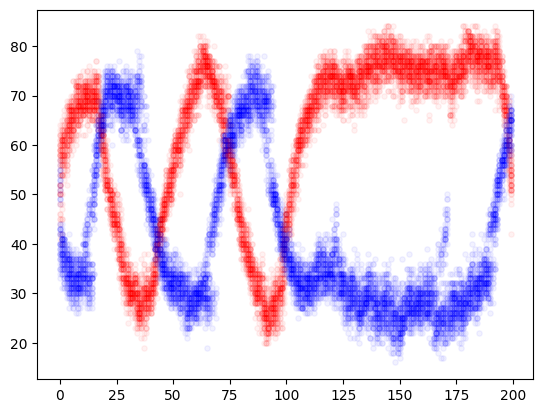

In [ ]:
for g in range(NGEN):
    offspringHost = toolbox.select(popHost, len(popHost))
    offspringHost = list(map(toolbox.clone, offspringHost))

    for m in offspringHost:
        toolbox.mutateHost(m)

    fitnessesHost = map(toolbox.evaluateHost, offspringHost)
    for ind, fit in zip(offspringHost, fitnessesHost):
        ind.fitness.values = fit

    for ind in popHost:
        ind.fitness.values = shared_fitness(ind, popHost)
    
    offspringParasite = toolbox.select(popParasite, len(popParasite))
    offspringParasite = list(map(toolbox.clone, offspringParasite))

    for m in offspringParasite:
        toolbox.mutateParasite(m)

    fitnessesParasite = map(toolbox.evaluateParasite, offspringParasite)
    for ind, fit in zip(offspringParasite, fitnessesParasite):
        ind.fitness.values = fit

    for ind in popParasite:
        ind.fitness.values = shared_fitness(ind, popParasite)

    popHost[:] = offspringHost
    popParasite[:] = offspringParasite

    gen = [g] * POPSIZE
    host = [sum(x) for x in popHost]
    parasite = [sum(x) for x in popParasite]
    plt.scatter( gen, host, color='red', s=15, alpha=0.05)
    plt.scatter( gen, parasite, color='blue', s=15, alpha=0.05)
    display.display(plt.gcf())
    display.clear_output(wait=True)

Here, g is the current generation, POPSIZE is your population size (assuming equal population sizes for each species here), popHost is your host population and popParasite is your parasite population.

# <span style="color:blue">Exercise 2: Diversity measures and general strategies</span>

You can see that short-term strategies and cycling can occur a lot. This is simply a property of this problem. However, transitivity can be a real issue when it comes to other problems. As you have seen in the lectures, diversity measures can help with not only this, but with evolvability in general (and are particularly important for coevolution and multi-objective evolution).

Fitness sharing is a commonly used diversity method that we will implement. Although it will not make much difference for this problem, the intention here is to understand how to implement it for this problem.

Here is the pseudocode for how you could implement it here. To calculate the shared fitness for individual i:

```
alpha = 0.5
sigma = 5

res = 0
for each individual j in the population
    calculate the genotype distance from i to j
    if distance < sigma
        res += 1 – (distance/sigma)**alpha
fitness = (original_fitness / res),    
```

For our binary genomes, we can calculate the difference between genomes using the Hamming distance, which simply returns the number of positions where the two individuals differ. Below is a Python implementation of Hamming distance between two genotypes (s1 and s2):

**Your task:** Implement fitness sharing for both populations.